In [1]:
import os, random, warnings, csv, json as _json, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def seed_everything(seed=7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(7)
print('Seed = 7')

Seed = 7


In [ ]:
# CONFIGURATION — adjust paths before running

TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
NEW_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
OOD_FOLDER      = os.path.join(NEW_DATA_ROOT, 'Dunite-Ecologite_2Rocks_1-83Hz')
RESULTS_DIR     = 'results_rock_classifier_multisource_v2'

ARCH            = 'resnet18'
USE_STRONG_AUG  = True
FREEZE_BACKBONE = False
EPOCHS          = 20
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
BATCH_SIZE      = 64
ORIG_TEST_SPLIT = 0.25   # fraction of original data held out for original-eval
OOD_FPR         = 0.05

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#59a14f']
OOD_COLOR    = '#e15759'
VALID_EXT    = ('.jpg', '.jpeg', '.bmp', '.png')

# ── Folder-based split: new data ────────────────────────────────
#
# NEW_TRAIN_SOURCES: added to training — model will see these
# NEW_TEST_SOURCES:  NEVER seen during training — the honest eval
#
# Design rationale:
#   Granite  — train on Gran_Phil (1+2), test on Gneis (most different)
#   Sandstone — no new training data; test SandstoneNew from original knowledge only
#   Limestone — train on CalcSil + Lst_Rax_1, test on Lst_Rax_2 (same quarry, unseen session)
#   Dunite   — fully OOD, kept out of everything

NEW_TRAIN_SOURCES = {
    'S10Granite': [
        os.path.join(NEW_DATA_ROOT, 'Granite_3SamplesPhilipp_1-83Hz_1'),
        os.path.join(NEW_DATA_ROOT, 'Granite_3SamplesPhilipp_1-83Hz_2'),
    ],
    'Holstein_Sandstone': [
        # intentionally empty — tests whether original training transfers
    ],
    'Leitendorf_Limestone': [
        os.path.join(NEW_DATA_ROOT, 'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz'),
        os.path.join(NEW_DATA_ROOT, 'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz'),
        os.path.join(NEW_DATA_ROOT, 'Limestone_Rax_1-83Hz_1'),
    ],
}

# These are NEVER touched during training.
# Evaluation on these = genuine generalisation test.
NEW_TEST_SOURCES = {
    'S10Granite':          os.path.join(NEW_DATA_ROOT, 'Gneis_1-83Hz'),
    'Holstein_Sandstone':  os.path.join(NEW_DATA_ROOT, 'SandstoneNew_1-83Hz'),
    'Leitendorf_Limestone':os.path.join(NEW_DATA_ROOT, 'Limestone_Rax_1-83Hz_2'),
}

OOD_FOLDER = os.path.join(NEW_DATA_ROOT, 'Dunite-Ecologite_2Rocks_1-83Hz')

# Result sub-folders
DIR_TRAIN = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL  = os.path.join(RESULTS_DIR, 'evaluation')
DIR_OOD   = os.path.join(RESULTS_DIR, 'ood_calibration')
DIR_INF   = os.path.join(RESULTS_DIR, 'new_rock_test')
DIR_CAM   = os.path.join(RESULTS_DIR, 'gradcam')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL, DIR_OOD, DIR_INF, DIR_CAM]:
    os.makedirs(d, exist_ok=True)

MODEL_183 = os.path.join(RESULTS_DIR, 'rock_classifier_resnet18_v2_1-83Hz.pth')
MODEL_510 = os.path.join(RESULTS_DIR, 'rock_classifier_resnet18_v2_5-10Hz.pth')

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  ARCH={ARCH}  EPOCHS={EPOCHS}  LR={LR}')
print(f'  USE_STRONG_AUG={USE_STRONG_AUG}  OOD_FPR={OOD_FPR}')
print(f'  Results -> {RESULTS_DIR}')

Config ready.
  ARCH=resnet18  EPOCHS=20  LR=0.0001
  USE_STRONG_AUG=True  OOD_FPR=0.05
  Results -> results_rock_classifier_multisource_v2


In [5]:
# TRANSFORMS — identical to all previous notebooks
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform_strong = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

train_transform_standard = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

active_train_transform = (
    train_transform_strong if USE_STRONG_AUG else train_transform_standard)
print(f'Transforms ready  [{"STRONG" if USE_STRONG_AUG else "standard"} augmentation]')

Transforms ready  [STRONG augmentation]


In [6]:
# DATASET CLASSES

class SpectralImageDataset(Dataset):
    """Labelled dataset — returns (image_tensor, label)."""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

class UnlabelledDataset(Dataset):
    """Unlabelled dataset — returns (image_tensor, filename) for inference."""
    def __init__(self, paths, transform=None):
        self.paths = paths; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, os.path.basename(self.paths[idx])

print('Dataset classes ready.')

Dataset classes ready.


In [7]:
# MODEL BUILDER + GRAD-CAM

def build_model(n_classes, arch='resnet18', freeze_backbone=False):
    if arch == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet34':
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    else:
        raise ValueError(f'Unknown arch: {arch}')
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith('fc'): p.requires_grad_(False)
    return model


class GradCAM:
    """Grad-CAM on last conv block."""
    def __init__(self, model):
        self.model = model; self._acts = self._grads = None
        target = model.layer4[-1]
        self._fh = target.register_forward_hook(
            lambda m, i, o: setattr(self, '_acts', o.detach()))
        self._bh = target.register_full_backward_hook(
            lambda m, gi, go: setattr(self, '_grads', go[0].detach()))
    def generate(self, img_t, class_idx=None):
        self.model.eval()
        out = self.model(img_t)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        w   = self._grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self._acts).sum(dim=1, keepdim=True))
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        cam = F.interpolate(cam, (224, 224), mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx
    def remove(self): self._fh.remove(); self._bh.remove()


_m = build_model(3, ARCH)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'{ARCH} | trainable params: {n_params:,}')
del _m

resnet18 | trainable params: 11,178,051


In [8]:
def files_from_folder(folder):
    """Return sorted list of valid image paths in a folder."""
    p = Path(folder)
    if not p.is_dir():
        raise FileNotFoundError(f'Not found: {folder}')
    return sorted([str(f) for f in p.iterdir()
                   if f.suffix.lower() in VALID_EXT])


def load_original_data(root):
    """
    Loads the original single-source training data.
    Folder name must contain the class name substring.
    Returns (paths, labels, source_tags).
    """
    paths, labels, tags = [], [], []
    for folder in sorted(os.listdir(root)):
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path): continue
        label = None
        for ci, cls in enumerate(CLASS_NAMES):
            if cls in folder:
                label = ci; break
        if label is None: continue
        imgs = files_from_folder(folder_path)
        paths.extend(imgs)
        labels.extend([label] * len(imgs))
        tags.extend([folder] * len(imgs))
        print(f'  [orig] {folder}: {len(imgs)} images  → {CLASS_NAMES[label]}')
    return paths, labels, tags


def load_new_train_data():
    """
    Loads new training sources. Returns (paths, labels, source_tags).
    """
    paths, labels, tags = [], [], []
    for cls_name, folders in NEW_TRAIN_SOURCES.items():
        ci = CLASS_NAMES.index(cls_name)
        for folder in folders:
            if not os.path.isdir(folder):
                print(f'  [MISSING] {folder}')
                continue
            imgs = files_from_folder(folder)
            tag  = os.path.basename(folder)
            paths.extend(imgs)
            labels.extend([ci] * len(imgs))
            tags.extend([tag] * len(imgs))
            print(f'  [new-train] {tag}: {len(imgs)} images  → {cls_name}')
    return paths, labels, tags


def load_new_test_data():
    """
    Loads new test sources. These are NEVER part of training.
    Returns dict: {class_name: (paths, label_int)}
    """
    result = {}
    for cls_name, folder in NEW_TEST_SOURCES.items():
        ci = CLASS_NAMES.index(cls_name)
        if not os.path.isdir(folder):
            print(f'  [MISSING] {folder}')
            continue
        imgs = files_from_folder(folder)
        tag  = os.path.basename(folder)
        result[cls_name] = {'paths': imgs, 'label': ci, 'tag': tag}
        print(f'  [new-test ] {tag}: {len(imgs)} images  → {cls_name}')
    return result


print('Data loading functions ready.')

Data loading functions ready.


In [9]:
# LOAD ALL DATA
print('=== Original data ===')
orig_paths, orig_labels, orig_tags = load_original_data(TRAIN_DATA_ROOT)
print(f'  Total original: {len(orig_paths)}')

print('\n=== New training data ===')
new_tr_paths, new_tr_labels, new_tr_tags = load_new_train_data()
print(f'  Total new-train: {len(new_tr_paths)}')

print('\n=== New test data (honest eval — never seen in training) ===')
new_test_data = load_new_test_data()
for cls, d in new_test_data.items():
    print(f'  {d["tag"]}: {len(d["paths"])} images')

# Stratified split of original data
orig_tr_p, orig_te_p, orig_tr_l, orig_te_l = train_test_split(
    orig_paths, orig_labels,
    test_size=ORIG_TEST_SPLIT, stratify=orig_labels, random_state=7)

print(f'\nOriginal split: train={len(orig_tr_p)}  test={len(orig_te_p)}')

# Combine: full training set = original train + new train sources
all_tr_paths  = orig_tr_p  + new_tr_paths
all_tr_labels = orig_tr_l  + new_tr_labels
all_tr_tags   = ['__orig__'] * len(orig_tr_p) + new_tr_tags

print(f'Full training set: {len(all_tr_paths)} images')
for ci, cls in enumerate(CLASS_NAMES):
    n = sum(1 for l in all_tr_labels if l == ci)
    print(f'  {cls}: {n}')

=== Original data ===
  [orig] Holstein_Sandstone_1-83Hz_Spectral: 4000 images  → Holstein_Sandstone
  [orig] Holstein_Sandstone_5-10Hz_Spectral: 4000 images  → Holstein_Sandstone
  [orig] Leitendorf_Limestone_1-83Hz_Spectral: 4076 images  → Leitendorf_Limestone
  [orig] Leitendorf_Limestone_5-10Hz_Spectral: 4035 images  → Leitendorf_Limestone
  [orig] S10Granite_1-83Hz_Spectral: 4003 images  → S10Granite
  [orig] S10Granite_5-10Hz_Spectral: 4155 images  → S10Granite
  Total original: 24269

=== New training data ===
  [new-train] Granite_3SamplesPhilipp_1-83Hz_1: 1000 images  → S10Granite
  [new-train] Granite_3SamplesPhilipp_1-83Hz_2: 490 images  → S10Granite
  [new-train] Limestone_CalcsilicaContaminated_U9_U3_1-83Hz: 1000 images  → Leitendorf_Limestone
  [new-train] Limestone_CalcsilicaContaminated_U9_U3_5-10Hz: 1000 images  → Leitendorf_Limestone
  [new-train] Limestone_Rax_1-83Hz_1: 25 images  → Leitendorf_Limestone
  Total new-train: 3515

=== New test data (honest eval — never 

[SAVED] results_rock_classifier_multisource_v2/training/TR-00_training_composition.png


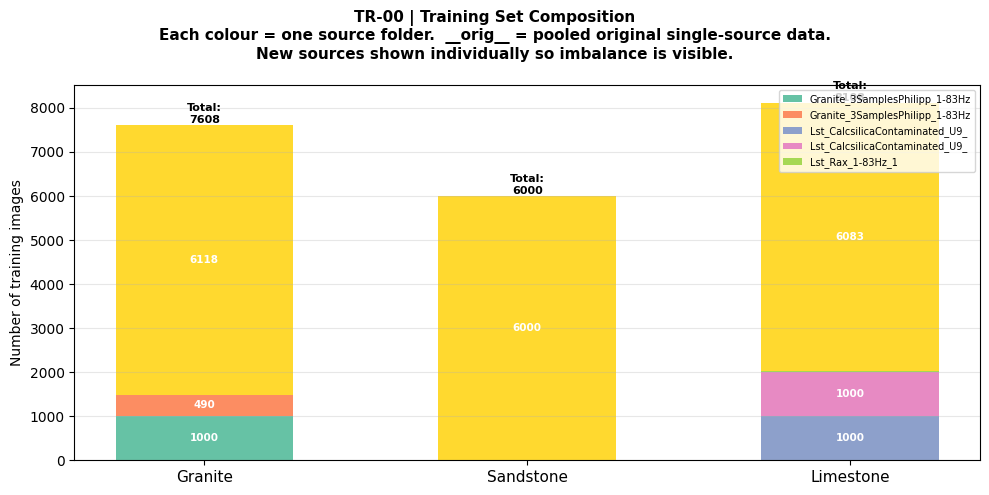


New test set (honest eval):
  Gneis_1-83Hz: 500 images
  SandstoneNew_1-83Hz: 21 images
  Limestone_Rax_1-83Hz_2: 20 images

  NOTE: SandstoneNew has no new training data — model must transfer from original Holstein.
  NOTE: Gneis has no Gneis in training — model must transfer from Gran_Phil.


In [10]:
# TR-00  Dataset composition — training set breakdown by source
# Shows how many images each source contributes per class.
# Original sources are grouped as '__orig__'.
# New sources are shown individually so you can see their relative weight.

source_counts = collections.Counter(zip(all_tr_labels, all_tr_tags))
all_sources   = sorted(set(all_tr_tags))
cmap = plt.cm.Set2(np.linspace(0, 1, max(8, len(all_sources))))

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    'TR-00 | Training Set Composition\n'
    'Each colour = one source folder.  __orig__ = pooled original single-source data.\n'
    'New sources shown individually so imbalance is visible.',
    fontsize=11, fontweight='bold')

x      = np.arange(len(CLASS_NAMES))
bottom = np.zeros(len(CLASS_NAMES))
for ci_s, src in enumerate(all_sources):
    vals = [source_counts.get((ci, src), 0) for ci in range(len(CLASS_NAMES))]
    if sum(vals) == 0: continue
    bars = ax.bar(x, vals, bottom=bottom, color=cmap[ci_s % 8],
                   label=src.replace('Limestone_', 'Lst_')[:30], width=0.55)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 80:
            ax.text(xi, b + v/2, str(v),
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold')
    bottom += np.array(vals)

totals = [sum(source_counts.get((ci, s), 0)
              for s in all_sources) for ci in range(len(CLASS_NAMES))]
for xi, tot in enumerate(totals):
    ax.text(xi, tot + 50, f'Total:\n{tot}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, fontsize=11)
ax.set_ylabel('Number of training images')
ax.legend(fontsize=7, loc='upper right', ncol=1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_TRAIN,
    'TR-00_training_composition.png',
    'Training set breakdown by source folder per class')
plt.show()

# Also print the new test set sizes for reference
print('\nNew test set (honest eval):')
for cls, d in new_test_data.items():
    print(f'  {d["tag"]}: {len(d["paths"])} images')
print('\n  NOTE: SandstoneNew has no new training data — model must transfer from original Holstein.')
print('  NOTE: Gneis has no Gneis in training — model must transfer from Gran_Phil.')

In [11]:
# WEIGHTED RANDOM SAMPLER
#
# Problem: original data has thousands of images per class.
# New sources have hundreds. Without weighting, the model barely
# sees the new sources — they contribute almost nothing to gradients.
#
# Fix: give each image a weight = 1 / (n_images_in_its_source).
# This makes every source contribute EQUALLY to each training epoch,
# regardless of how many images it has.

def make_weighted_sampler(tags):
    tag_counts = collections.Counter(tags)
    weights    = [1.0 / tag_counts[t] for t in tags]
    return WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True)

sampler_train = make_weighted_sampler(all_tr_tags)

# Print effective weight ratio to show what changed
tag_counts = collections.Counter(all_tr_tags)
print('Effective per-sample weights (relative to largest source):')
max_count = max(tag_counts.values())
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1]):
    relative = max_count / count
    print(f'  {tag[:50]:<50}  n={count:>6}  weight={relative:.1f}x')
print('\nSmall sources are upweighted so each epoch sees them proportionally.')

Effective per-sample weights (relative to largest source):
  __orig__                                            n= 18201  weight=1.0x
  Granite_3SamplesPhilipp_1-83Hz_1                    n=  1000  weight=18.2x
  Limestone_CalcsilicaContaminated_U9_U3_1-83Hz       n=  1000  weight=18.2x
  Limestone_CalcsilicaContaminated_U9_U3_5-10Hz       n=  1000  weight=18.2x
  Granite_3SamplesPhilipp_1-83Hz_2                    n=   490  weight=37.1x
  Limestone_Rax_1-83Hz_1                              n=    25  weight=728.0x

Small sources are upweighted so each epoch sees them proportionally.


In [12]:
# BUILD DATASETS
train_ds = SpectralImageDataset(all_tr_paths, all_tr_labels, active_train_transform)
orig_test_ds = SpectralImageDataset(orig_te_p, orig_te_l, eval_transform)

print(f'Training dataset:       {len(train_ds)} images')
print(f'Original test dataset:  {len(orig_test_ds)} images (original classes only)')
print(f'New test data:')
for cls, d in new_test_data.items():
    print(f'  {d["tag"]}: {len(d["paths"])} images')

Training dataset:       21716 images
Original test dataset:  6068 images (original classes only)
New test data:
  Gneis_1-83Hz: 500 images
  SandstoneNew_1-83Hz: 21 images
  Limestone_Rax_1-83Hz_2: 20 images


In [13]:
def train_model(train_ds, val_ds, model_save_path, speed_tag):
    if os.path.exists(model_save_path):
        print(f'[SKIP] {os.path.basename(model_save_path)} exists — delete to retrain.')
        return None

    seed_everything(7)
    print(f'\nTraining [{speed_tag}]  n_train={len(train_ds)}  n_val={len(val_ds)}')

    nw      = min(4, os.cpu_count() or 1)
    pin     = (device.type == 'cuda')
    sampler = make_weighted_sampler(all_tr_tags)

    # sampler and shuffle are mutually exclusive in DataLoader
    tr_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))
    va_ldr = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))

    model     = build_model(len(CLASS_NAMES), ARCH, FREEZE_BACKBONE).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)
    warmup    = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=2)
    criterion = nn.CrossEntropyLoss()
    use_amp   = (device.type == 'cuda')
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    tr_accs, va_accs, tr_losses, va_losses = [], [], [], []
    best_acc = -1.0

    for epoch in range(EPOCHS):
        model.train()
        ep_loss, ep_acc = [], []
        for Xb, yb in tqdm(tr_ldr, desc=f'Ep{epoch+1:>2} train', leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out  = model(Xb); loss = criterion(out, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer); scaler.update()
            else:
                out  = model(Xb); loss = criterion(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            ep_loss.append(loss.item())
            ep_acc.append((out.argmax(1) == yb).float().mean().item())

        tr_accs.append(float(np.mean(ep_acc)))
        tr_losses.append(float(np.mean(ep_loss)))

        model.eval()
        vl, va = [], []
        with torch.no_grad():
            for Xb, yb in va_ldr:
                Xb, yb = Xb.to(device), yb.to(device)
                out    = model(Xb); loss = criterion(out, yb)
                vl.append(loss.item())
                va.append((out.argmax(1) == yb).float().mean().item())
        val_acc = float(np.mean(va))
        va_accs.append(val_acc)
        va_losses.append(float(np.mean(vl)))

        if epoch < 2: warmup.step()
        else:         scheduler.step(val_acc)

        saved = ''
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            saved = ' [SAVED]'

        print(f'  Ep {epoch+1:>2}/{EPOCHS}  '
              f'tr={tr_accs[-1]*100:.2f}%  '
              f'val={val_acc*100:.2f}%{saved}')

    print(f'  Best val (original held-out): {best_acc*100:.2f}%')
    with open(model_save_path.replace('.pth', '_class_names.json'), 'w') as jf:
        _json.dump(CLASS_NAMES, jf)
    del model, optimizer, criterion
    if scaler: del scaler
    torch.cuda.empty_cache()
    return dict(tr_accs=tr_accs, va_accs=va_accs,
                tr_losses=tr_losses, va_losses=va_losses, best_acc=best_acc)

print('train_model() defined.')

train_model() defined.


In [14]:
# NOTE: Both belt speeds use the same training set here (1.83 Hz dominant).
# If you have separate 5.10 Hz new data, adjust sources_510 in the config.
# For now we train one model on all available data.

hist = train_model(train_ds, orig_test_ds, MODEL_183, '1.83 Hz (all sources)')


Training [1.83 Hz (all sources)]  n_train=21716  n_val=6068


  Ep  1/20  tr=80.47%  val=56.32% [SAVED]


  Ep  2/20  tr=88.96%  val=58.34% [SAVED]


  Ep  3/20  tr=91.03%  val=76.99% [SAVED]


  Ep  4/20  tr=92.94%  val=72.57%


...

  Ep 16/20  tr=96.95%  val=93.96% [SAVED]


  Ep 17/20  tr=97.26%  val=84.72%


  Ep 18/20  tr=97.16%  val=87.77%


  Ep 19/20  tr=97.36%  val=91.67%


  Ep 20/20  tr=97.65%  val=57.84%
  Best val (original held-out): 93.96%


[SAVED] results_rock_classifier_multisource_v2/training/TR-01_training_history_v2.png


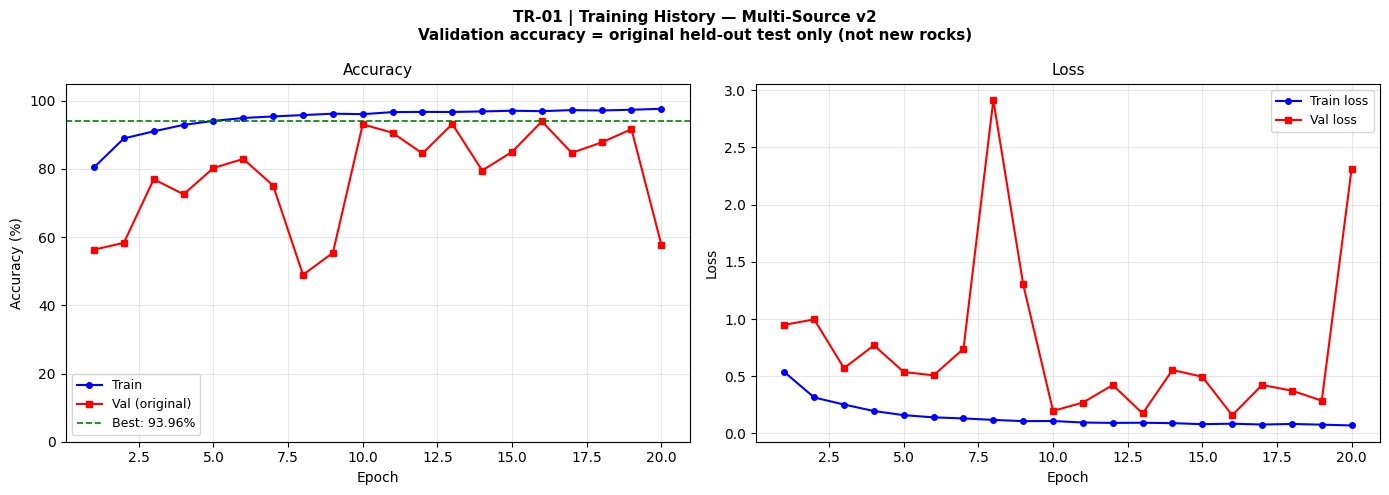

In [15]:
# TR-01  Training history
if hist is not None:
    ep = range(1, EPOCHS + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        'TR-01 | Training History — Multi-Source v2\n'
        'Validation accuracy = original held-out test only (not new rocks)',
        fontsize=11, fontweight='bold')

    axes[0].plot(ep, np.array(hist['tr_accs']) * 100, 'b-o', ms=4, label='Train')
    axes[0].plot(ep, np.array(hist['va_accs']) * 100, 'r-s', ms=4, label='Val (original)')
    axes[0].axhline(hist['best_acc'] * 100, color='green', ls='--', lw=1.2,
                    label=f'Best: {hist["best_acc"]*100:.2f}%')
    axes[0].set_title('Accuracy', fontsize=11)
    axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
    axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, hist['tr_losses'], 'b-o', ms=4, label='Train loss')
    axes[1].plot(ep, hist['va_losses'], 'r-s', ms=4, label='Val loss')
    axes[1].set_title('Loss', fontsize=11)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_fig(fig, DIR_TRAIN, 'TR-01_training_history_v2.png',
        'Training and validation accuracy/loss curves for multisource v2 model')
    plt.show()
else:
    print('Model loaded from disk — no training history to plot.')

In [16]:
# LOAD MODEL
def load_model(path):
    model = build_model(len(CLASS_NAMES), ARCH, False).to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

model = load_model(MODEL_183)
print(f'Model loaded <- {MODEL_183}')

Model loaded <- results_rock_classifier_multisource_v2/rock_classifier_resnet18_v2_1-83Hz.pth


In [17]:
def collect_logits(model, paths, labels):
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = SpectralImageDataset(paths, labels, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))
    all_logits, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for Xb, yb in ldr:
            logits = model(Xb.to(device)).cpu()
            all_logits.append(logits)
            all_labels.extend(yb.tolist())
            all_preds.extend(logits.argmax(1).tolist())
    return torch.cat(all_logits, 0), np.array(all_labels), np.array(all_preds)


print('Evaluating on original held-out test set...')
logits_orig, labels_orig, preds_orig = collect_logits(model, orig_te_p, orig_te_l)
acc_orig = np.mean(preds_orig == labels_orig) * 100
print(f'  Original test accuracy: {acc_orig:.2f}%')
print(f'  (Single-source baseline was ~99.6% — compare here)')
print()
print(classification_report(labels_orig, preds_orig, target_names=CLASS_NAMES, digits=4))

Evaluating on original held-out test set...
  Original test accuracy: 93.97%
  (Single-source baseline was ~99.6% — compare here)

                      precision    recall  f1-score   support

          S10Granite     0.9892    0.9843    0.9867      2040
  Holstein_Sandstone     0.9828    0.8565    0.9153      2000
Leitendorf_Limestone     0.8632    0.9768    0.9165      2028

            accuracy                         0.9397      6068
           macro avg     0.9450    0.9392    0.9395      6068
        weighted avg     0.9450    0.9397    0.9397      6068



[SAVED] results_rock_classifier_multisource_v2/evaluation/EV-01_confusion_original_test.png


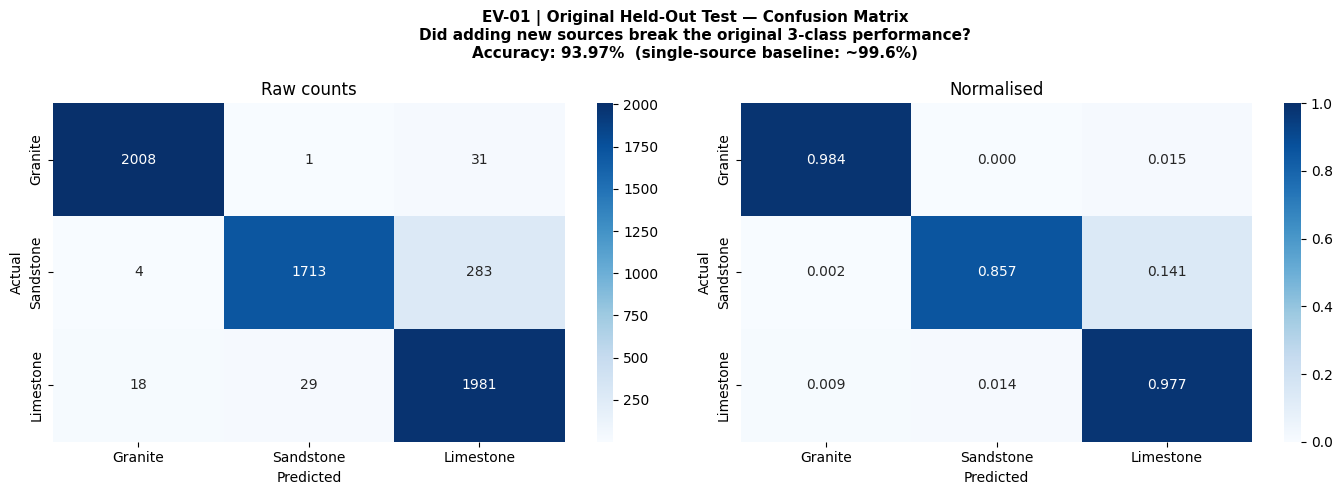

In [18]:
# EV-01  Confusion matrix — original held-out test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'EV-01 | Original Held-Out Test — Confusion Matrix\n'
    'Did adding new sources break the original 3-class performance?\n'
    f'Accuracy: {acc_orig:.2f}%  (single-source baseline: ~99.6%)',
    fontsize=11, fontweight='bold')

cm  = confusion_matrix(labels_orig, preds_orig)
cmn = cm.astype(float)
rs  = cm.sum(axis=1, keepdims=True)
np.divide(cmn, rs, out=cmn, where=rs != 0)

sns.heatmap(cm,  ax=axes[0], annot=True, fmt='d', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
axes[0].set_title('Raw counts'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

sns.heatmap(cmn, ax=axes[1], annot=True, fmt='.3f', cmap='Blues',
            vmin=0, vmax=1,
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
axes[1].set_title('Normalised'); axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
save_fig(fig, DIR_EVAL, 'EV-01_confusion_original_test.png',
    'Confusion matrix on original held-out test — checks for regression')
plt.show()

In [19]:
def evaluate_folder(model, paths, true_label_int):
    """Run model on a folder of images and return predictions + confidence."""
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = UnlabelledDataset(paths, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))
    preds, confs, probs_all = [], [], []
    with torch.no_grad():
        for Xb, _ in ldr:
            probs = torch.softmax(model(Xb.to(device)), dim=1).cpu().numpy()
            for prob in probs:
                preds.append(int(np.argmax(prob)))
                confs.append(float(np.max(prob)))
                probs_all.append(prob.tolist())
    preds     = np.array(preds)
    labels    = np.array([true_label_int] * len(preds))
    accuracy  = np.mean(preds == labels) * 100
    mean_conf = np.mean(confs) * 100
    top_pred  = CLASS_NAMES[int(np.bincount(preds).argmax())]
    return dict(preds=preds, confs=confs, probs_all=probs_all,
                accuracy=accuracy, mean_conf=mean_conf, top_pred=top_pred,
                n=len(preds))


print('=' * 70)
print('NEW ROCK GENERALISATION TEST — honest evaluation')
print('=' * 70)
print(f'  {"Folder":<45} {"Expected":<12} {"Top pred":<12}',
      f'{"Accuracy":>9} {"Mean conf":>9}')
print('-' * 90)

new_test_results = {}
for cls_name, d in new_test_data.items():
    res = evaluate_folder(model, d['paths'], d['label'])
    new_test_results[cls_name] = res
    verdict = '✅' if res['accuracy'] >= 50 else '❌'
    print(f'  {d["tag"]:<45} {cls_name.split("_")[0]:<12} '
          f'{res["top_pred"].split("_")[0]:<12} '
          f'{res["accuracy"]:>8.1f}% {res["mean_conf"]:>8.1f}%  {verdict}')

print('=' * 90)

NEW ROCK GENERALISATION TEST — honest evaluation
  Folder                                        Expected     Top pred      Accuracy Mean conf
------------------------------------------------------------------------------------------
  Gneis_1-83Hz                                  S10Granite   S10Granite       75.2%     92.7%  ✅
  SandstoneNew_1-83Hz                           Holstein     Leitendorf        9.5%     79.2%  ❌
  Limestone_Rax_1-83Hz_2                        Leitendorf   Leitendorf       70.0%     89.5%  ✅


[SAVED] results_rock_classifier_multisource_v2/new_rock_test/EV-02_confidence_histograms_new_test.png


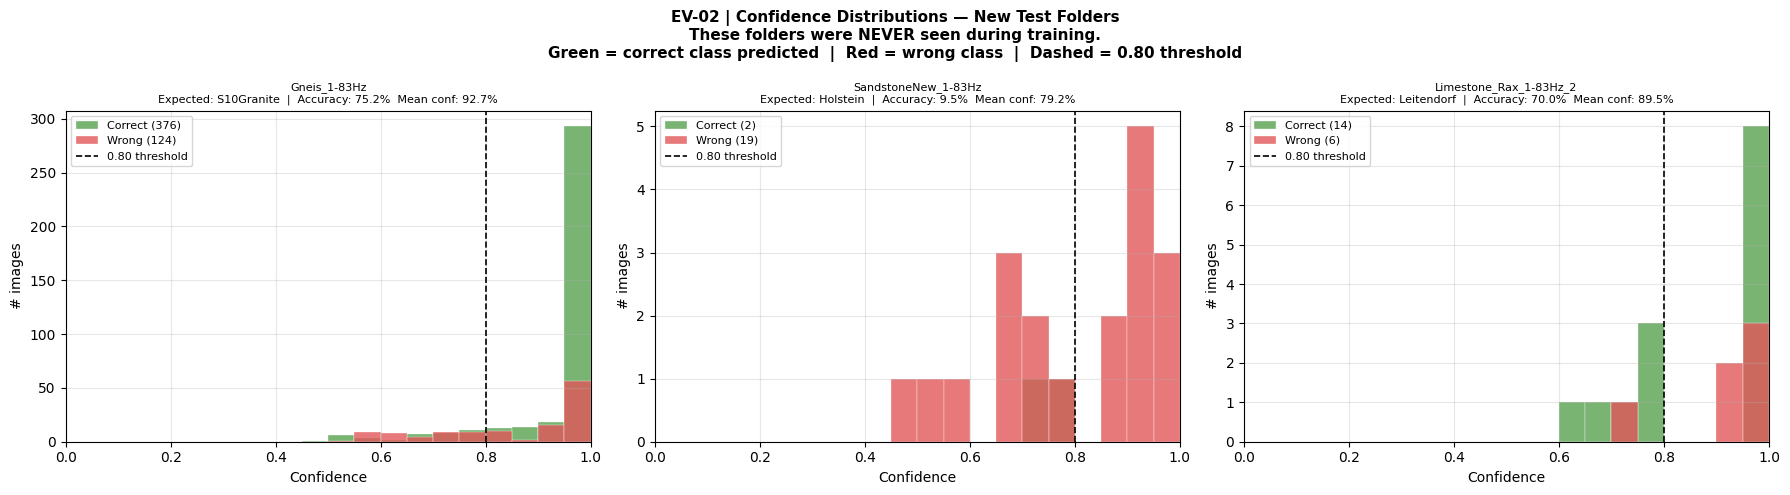

In [20]:
# EV-02  Per-image confidence histograms for each new test folder
# What it shows:
#   Spike near 1.0 = model is confident about that rock (good if correct class)
#   Spread distribution = model is uncertain
#   Cluster near 0.33 = model has no idea (3-class uniform distribution)

n_folders = len(new_test_results)
fig, axes = plt.subplots(1, n_folders, figsize=(6 * n_folders, 5))
if n_folders == 1: axes = [axes]
fig.suptitle(
    'EV-02 | Confidence Distributions — New Test Folders\n'
    'These folders were NEVER seen during training.\n'
    'Green = correct class predicted  |  Red = wrong class  |  Dashed = 0.80 threshold',
    fontsize=11, fontweight='bold')

for ax, (cls_name, res) in zip(axes, new_test_results.items()):
    true_ci = new_test_data[cls_name]['label']
    colors  = ['#59a14f' if p == true_ci else '#e15759' for p in res['preds']]
    correct_confs = [c for p, c in zip(res['preds'], res['confs']) if p == true_ci]
    wrong_confs   = [c for p, c in zip(res['preds'], res['confs']) if p != true_ci]

    if correct_confs:
        ax.hist(correct_confs, bins=20, range=(0, 1), color='#59a14f', alpha=0.8,
                label=f'Correct ({len(correct_confs)})', edgecolor='white', lw=0.3)
    if wrong_confs:
        ax.hist(wrong_confs, bins=20, range=(0, 1), color='#e15759', alpha=0.8,
                label=f'Wrong ({len(wrong_confs)})', edgecolor='white', lw=0.3)

    ax.axvline(0.80, color='black', ls='--', lw=1.2, label='0.80 threshold')
    ax.set_title(
        f'{new_test_data[cls_name]["tag"]}\n'
        f'Expected: {cls_name.split("_")[0]}  |  '
        f'Accuracy: {res["accuracy"]:.1f}%  Mean conf: {res["mean_conf"]:.1f}%',
        fontsize=8)
    ax.set_xlabel('Confidence'); ax.set_ylabel('# images')
    ax.set_xlim(0, 1); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, DIR_INF, 'EV-02_confidence_histograms_new_test.png',
    'Per-image confidence distributions for each new test folder (never seen in training)')
plt.show()

[SAVED] results_rock_classifier_multisource_v2/new_rock_test/EV-03_mean_softmax_new_test.png


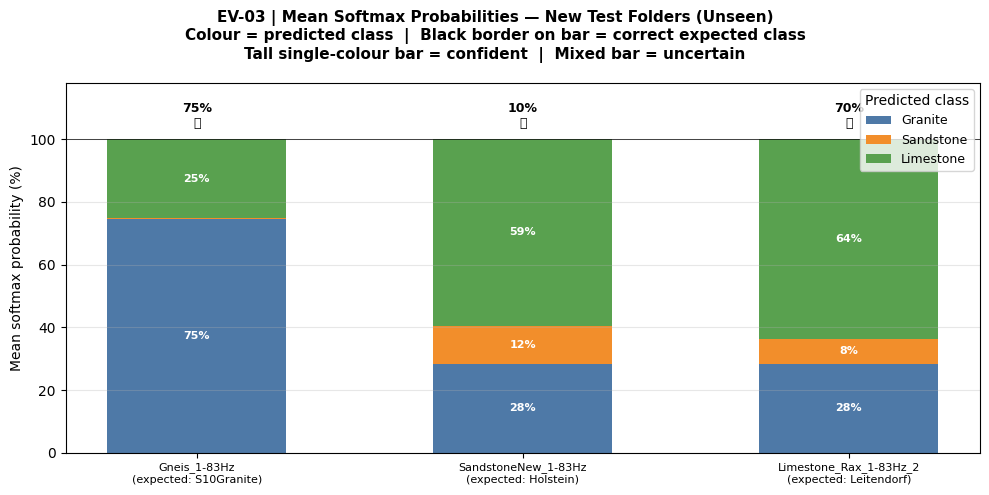

In [21]:
# EV-03  Mean softmax probability vector per new test folder
# Shows where the probability mass sits across all 3 classes.
# A correct result: tall bar of the right colour.
# A wrong result: tall bar of the wrong colour.
# Uncertain: roughly equal bars.

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    'EV-03 | Mean Softmax Probabilities — New Test Folders (Unseen)\n'
    'Colour = predicted class  |  Black border on bar = correct expected class\n'
    'Tall single-colour bar = confident  |  Mixed bar = uncertain',
    fontsize=11, fontweight='bold')

folder_tags = [new_test_data[cls]['tag'] for cls in new_test_results]
mean_probs  = np.array([
    np.mean(new_test_results[cls]['probs_all'], axis=0)
    for cls in new_test_results
])

x      = np.arange(len(folder_tags))
bottom = np.zeros(len(folder_tags))
for ci, (cls, color, short) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, SHORT_NAMES)):
    vals = mean_probs[:, ci] * 100
    ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.55)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(xi, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

# Annotate accuracy above each bar
for xi, cls_name in enumerate(new_test_results):
    acc = new_test_results[cls_name]['accuracy']
    icon = '✅' if acc >= 50 else '❌'
    ax.text(xi, 103, f'{acc:.0f}%\n{icon}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{new_test_data[cls]['tag']}\n(expected: {cls.split('_')[0]})" for cls in new_test_results],
    fontsize=8)
ax.set_ylabel('Mean softmax probability (%)')
ax.set_ylim(0, 118)
ax.set_yticks(range(0, 101, 20))
ax.legend(title='Predicted class', loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(100, color='black', lw=0.5)

plt.tight_layout()
save_fig(fig, DIR_INF, 'EV-03_mean_softmax_new_test.png',
    'Mean softmax probability per class for each new test folder')
plt.show()

In [22]:
# Temperature scaling + energy score — calibrated on original held-out test

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def calibrate(self, logits, labels):
        opt  = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        crit = nn.CrossEntropyLoss()
        def step():
            opt.zero_grad()
            loss = crit(logits / self.temperature.clamp(min=0.05), labels)
            loss.backward(); return loss
        opt.step(step)
        self.temperature.data = self.temperature.clamp(min=0.05)
        return self.temperature.item()
    def scale(self, logits):
        return logits / self.temperature.clamp(min=0.05)
    def energy(self, logits):
        return (-self.temperature.item()
                * torch.logsumexp(self.scale(logits), dim=1)).detach().numpy()


ood_scaler = TemperatureScaler()
T = ood_scaler.calibrate(
    logits_orig,
    torch.tensor(labels_orig, dtype=torch.long))

energy_orig    = ood_scaler.energy(logits_orig)
ood_threshold  = float(np.percentile(energy_orig, (1 - OOD_FPR) * 100))
actual_fpr     = np.mean(energy_orig > ood_threshold) * 100

print(f'Temperature T = {T:.4f}')
print(f'OOD threshold = {ood_threshold:.4f}  (calibrated at {OOD_FPR*100:.0f}% FPR)')
print(f'Actual FPR on original val: {actual_fpr:.2f}%')

Temperature T = 1.3963
OOD threshold = -2.5537  (calibrated at 5% FPR)
Actual FPR on original val: 5.01%


In [26]:
# DUNITE OOD TEST
dunite_paths = sorted([
    str(f) for f in Path(OOD_FOLDER).iterdir()
    if f.suffix.lower() in VALID_EXT])
print(f'Dunite images: {len(dunite_paths)}')

# Collect logits
nw  = min(4, os.cpu_count() or 1)
pin = (device.type == 'cuda')
ds  = UnlabelledDataset(dunite_paths, eval_transform)
ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                  num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))
dun_logits_list = []
with torch.no_grad():
    for Xb, _ in ldr:
        dun_logits_list.append(model(Xb.to(device)).cpu())
dun_logits    = torch.cat(dun_logits_list, 0)
dun_energies  = ood_scaler.energy(dun_logits)
dun_probs = torch.softmax(ood_scaler.scale(dun_logits), dim=1).detach().numpy()
dun_preds     = dun_probs.argmax(axis=1)
dun_ood_flags = dun_energies > ood_threshold

n_ood   = dun_ood_flags.sum()
n_total = len(dunite_paths)
print(f'Flagged as OOD: {n_ood}/{n_total}  ({n_ood/n_total*100:.1f}%)')
print(f'Mean energy: {dun_energies.mean():.4f}  threshold: {ood_threshold:.4f}')
verdict = 'PASS — majority flagged as Unknown' if n_ood / n_total > 0.5 else 'FAIL — not reliably detected as OOD'
print(f'Verdict: {verdict}')

Dunite images: 500


Flagged as OOD: 10/500  (2.0%)
Mean energy: -5.0399  threshold: -2.5537
Verdict: FAIL — not reliably detected as OOD


[SAVED] results_rock_classifier_multisource_v2/ood_calibration/OOD-01_energy_dunite_vs_known.png


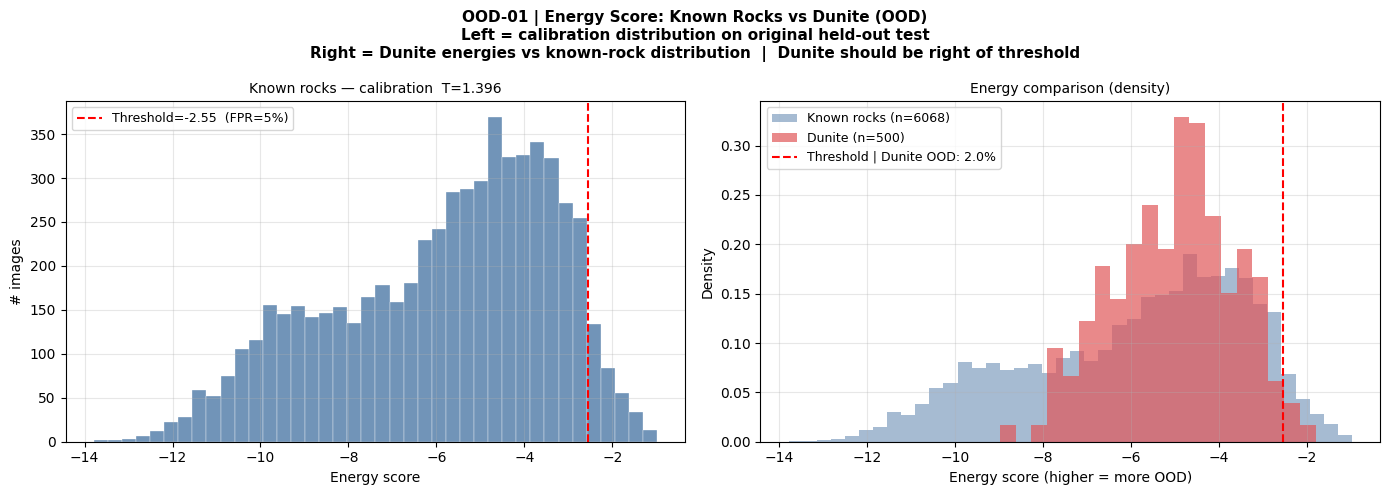

In [27]:
# OOD-01  Energy distributions: original known rocks vs Dunite
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'OOD-01 | Energy Score: Known Rocks vs Dunite (OOD)\n'
    'Left = calibration distribution on original held-out test\n'
    'Right = Dunite energies vs known-rock distribution  |  Dunite should be right of threshold',
    fontsize=11, fontweight='bold')

axes[0].hist(energy_orig, bins=40, color='#4e79a7', alpha=0.8, edgecolor='white', lw=0.3)
axes[0].axvline(ood_threshold, color='red', ls='--', lw=1.5,
                label=f'Threshold={ood_threshold:.2f}  (FPR={OOD_FPR*100:.0f}%)')
axes[0].set_title(f'Known rocks — calibration  T={T:.3f}', fontsize=10)
axes[0].set_xlabel('Energy score'); axes[0].set_ylabel('# images')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].hist(energy_orig, bins=40, color='#4e79a7', alpha=0.5, density=True,
             label=f'Known rocks (n={len(energy_orig)})')
axes[1].hist(dun_energies, bins=20, color=OOD_COLOR, alpha=0.7, density=True,
             label=f'Dunite (n={n_total})')
axes[1].axvline(ood_threshold, color='red', ls='--', lw=1.5,
                label=f'Threshold | Dunite OOD: {n_ood/n_total*100:.1f}%')
axes[1].set_title('Energy comparison (density)', fontsize=10)
axes[1].set_xlabel('Energy score (higher = more OOD)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_OOD, 'OOD-01_energy_dunite_vs_known.png',
    'Energy score distributions: known rocks vs Dunite OOD test')
plt.show()

In [37]:
# --- 1. GATHER DATA ---
feat_chunks, lbl_chunks = [], []

# Training
for ci, cls_name in enumerate(CLASS_NAMES):
    cls_paths = [p for p, l in zip(all_tr_paths, all_tr_labels) if l == ci]
    f, _ = extract_features(model, cls_paths, eval_transform, max_samples=300)
    feat_chunks.append(f)
    lbl_chunks.extend([f'Train: {SHORT_NAMES[ci]}'] * len(f))

# Test
for (cls_name, d) in new_test_data.items():
    f, _ = extract_features(model, d['paths'], eval_transform)
    feat_chunks.append(f)
    lbl_chunks.extend([f'TEST: {d["tag"][:20]}'] * len(f))

# Dunite
f_dun, _ = extract_features(model, dunite_paths, eval_transform, max_samples=300)
feat_chunks.append(f_dun)
lbl_chunks.extend(['Dunite (OOD)'] * len(f_dun))

X_all   = np.vstack(feat_chunks)
lbl_all = np.array(lbl_chunks)

# --- 2. CALCULATE TSNE ---
from sklearn.manifold import TSNE
seed_everything(7)
print(f'Running t-SNE on {X_all.shape[0]} samples... (Please wait)')

# THIS IS THE LINE THAT CREATES THE MISSING VARIABLE
tsne_2d = TSNE(n_components=2, perplexity=40, random_state=7, max_iter=1000).fit_transform(X_all)

print('Done! You can now run the plotting cell.')

Running t-SNE on 1741 samples... (Please wait)
Done! You can now run the plotting cell.


In [38]:
print(type(tsne_2d))
print(tsne_2d.shape)

<class 'numpy.ndarray'>
(1741, 2)


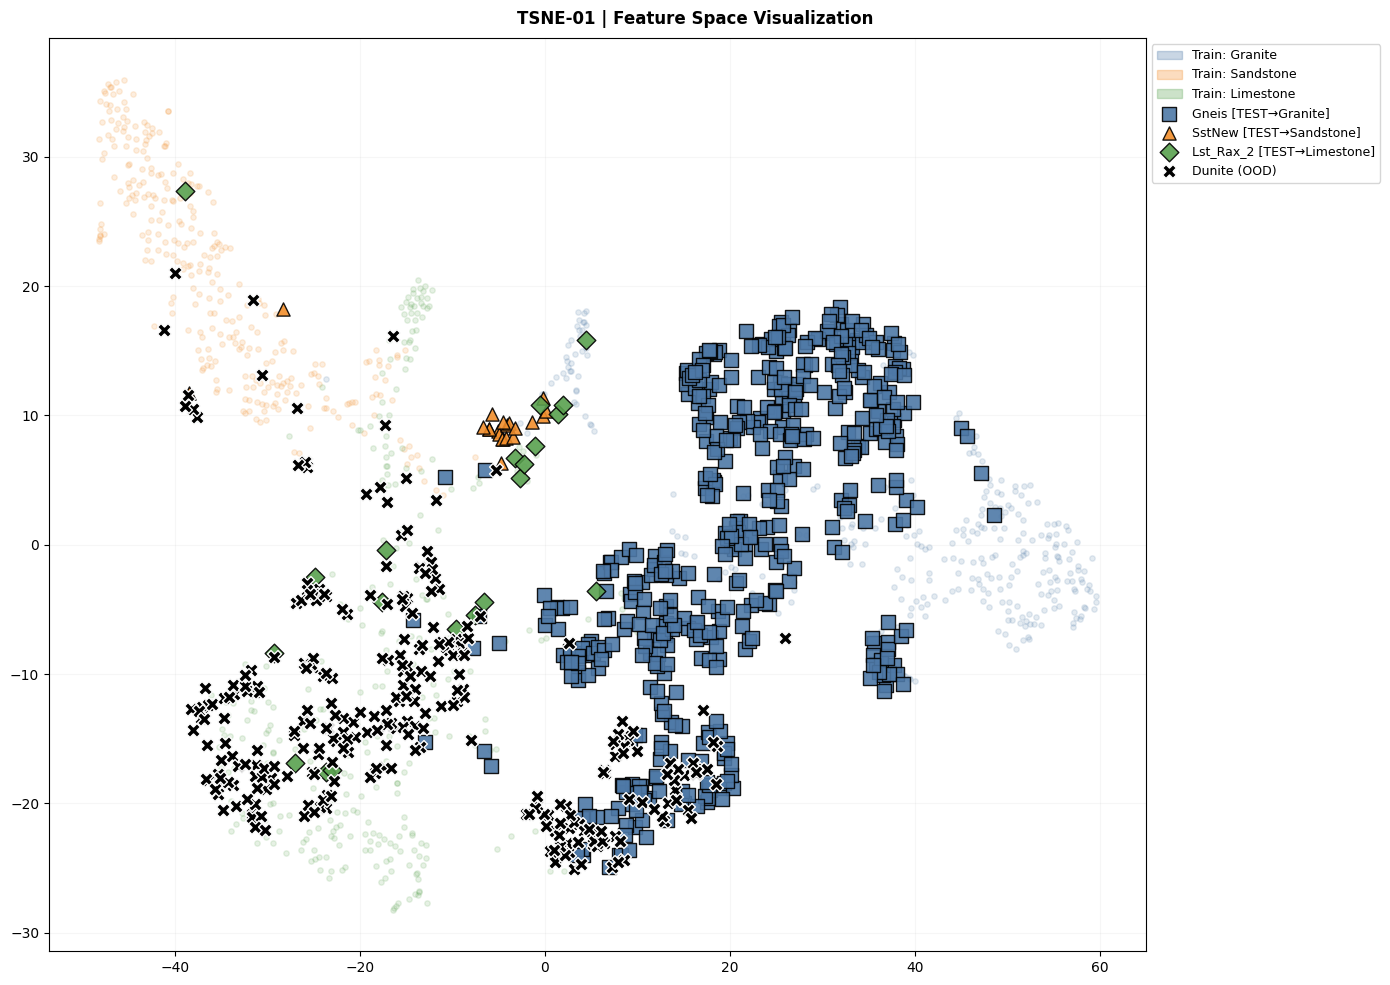

In [39]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('TSNE-01 | Feature Space Visualization', fontsize=12, fontweight='bold')

# 1. Training clusters (faint circles)
for s, c in zip(SHORT_NAMES, CLASS_COLORS):
    lbl = f'Train: {s}'
    mask = (lbl_all == lbl)
    ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], c=c, s=15, alpha=0.15, marker='o', zorder=1)

# 2. New Test Folders (bold markers)
test_config = {
    'S10Granite':           ('#4e79a7', 's', 'Gneis [TEST→Granite]'),
    'Holstein_Sandstone':   ('#f28e2b', '^', 'SstNew [TEST→Sandstone]'),
    'Leitendorf_Limestone': ('#59a14f', 'D', 'Lst_Rax_2 [TEST→Limestone]'),
}
for cls_key, (color, mkr, leg_label) in test_config.items():
    if cls_key not in new_test_data: continue
    tag = f'TEST: {new_test_data[cls_key]["tag"][:20]}'
    mask = (lbl_all == tag)
    ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], c=color, s=90, alpha=0.9, 
               marker=mkr, edgecolors='black', label=leg_label, zorder=3)

# 3. Dunite OOD
mask_dun = (lbl_all == 'Dunite (OOD)')
ax.scatter(tsne_2d[mask_dun, 0], tsne_2d[mask_dun, 1], c='black', s=100, alpha=1.0, 
           marker='X', edgecolors='white', label='Dunite (OOD)', zorder=4)

# Legend construction
train_patches = [mpatches.Patch(color=c, alpha=0.3, label=f'Train: {s}') for s, c in zip(SHORT_NAMES, CLASS_COLORS)]
test_handles, test_labels = ax.get_legend_handles_labels()
ax.legend(handles=train_patches + test_handles, loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)

ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

In [40]:
# FINAL SUMMARY TABLE
print('=' * 80)
print('MULTI-SOURCE v2 — FINAL RESULTS')
print('=' * 80)
print()
print(f'Original held-out test accuracy: {acc_orig:.2f}%')
print(f'  (Single-source baseline was ~99.6% — regression check)')
print()
print('NEW ROCK GENERALISATION (the honest numbers):')
print(f'  {"Folder":<45} {"Expected":<12} {"In training?":<15}',
      f'{"Accuracy":>9} {"Mean conf":>9}  Verdict')
print('-' * 110)

# Single-source baseline results (from inference_new_data.ipynb)
baseline = {
    'S10Granite':           ('S10Granite',   99.8, 'Limestone', 'wrong class'),
    'Holstein_Sandstone':   ('Holstein',      98.5, 'Limestone', 'wrong class'),
    'Leitendorf_Limestone': ('Limestone',     99.6, 'Limestone', 'correct'),
}

for cls_name, res in new_test_results.items():
    d       = new_test_data[cls_name]
    in_tr   = ', '.join(os.path.basename(f)
                        for f in NEW_TRAIN_SOURCES.get(cls_name, []))
    in_tr   = in_tr[:14] if in_tr else 'none'
    verdict = '✅ CORRECT' if res['accuracy'] >= 50 else '❌ WRONG'
    print(f'  {d["tag"]:<45} {cls_name.split("_")[0]:<12} {in_tr:<15}',
          f'{res["accuracy"]:>8.1f}% {res["mean_conf"]:>8.1f}%  {verdict}')

print()
print(f'Dunite OOD detection: {n_ood}/{n_total} ({n_ood/n_total*100:.1f}%) flagged')
print(f'  {verdict}')
print('=' * 80)
print()
print('COMPARISON WITH SINGLE-SOURCE MODEL (inference_new_data.ipynb):')
print(f'  Single-source — Gneis: predicted Granite @ 96.5%  (correct!)')
print(f'  Single-source — SstNew: predicted Limestone @ 98.5%  (wrong — spectrally ambiguous)')
print(f'  Single-source — Lst_Rax_2: predicted Limestone @ 99.6%  (correct)')
print()
print('If this model performs worse on any of these → weighting or architecture needs tuning.')
print('If SandstoneNew is still wrong → the spectrum genuinely resembles Limestone (physical overlap).')

MULTI-SOURCE v2 — FINAL RESULTS

Original held-out test accuracy: 93.97%
  (Single-source baseline was ~99.6% — regression check)

NEW ROCK GENERALISATION (the honest numbers):
  Folder                                        Expected     In training?     Accuracy Mean conf  Verdict
--------------------------------------------------------------------------------------------------------------
  Gneis_1-83Hz                                  S10Granite   Granite_3Sampl      75.2%     92.7%  ✅ CORRECT
  SandstoneNew_1-83Hz                           Holstein     none                 9.5%     79.2%  ❌ WRONG
  Limestone_Rax_1-83Hz_2                        Leitendorf   Limestone_Calc      70.0%     89.5%  ✅ CORRECT

Dunite OOD detection: 10/500 (2.0%) flagged
  ✅ CORRECT

COMPARISON WITH SINGLE-SOURCE MODEL (inference_new_data.ipynb):
  Single-source — Gneis: predicted Granite @ 96.5%  (correct!)
  Single-source — SstNew: predicted Limestone @ 98.5%  (wrong — spectrally ambiguous)
  Single-sour

In [41]:
# SAVE CSVs

# New test predictions
csv_new = os.path.join(RESULTS_DIR, 'predictions_new_test_folders.csv')
with open(csv_new, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['folder', 'expected_class', 'predicted_class', 'correct',
                'confidence', 'prob_S10Granite',
                'prob_Holstein_Sandstone', 'prob_Leitendorf_Limestone'])
    for cls_name, res in new_test_results.items():
        d = new_test_data[cls_name]
        paths = d['paths']
        for i, (pred, conf, probs) in enumerate(
                zip(res['preds'], res['confs'], res['probs_all'])):
            w.writerow([
                d['tag'], cls_name, CLASS_NAMES[pred],
                int(pred == d['label']),
                round(conf, 4),
                round(probs[0], 4), round(probs[1], 4), round(probs[2], 4)
            ])
_saved_files.append((csv_new, 'Per-image predictions for new test folders (honest eval)'))
print(f'[SAVED] {csv_new}')

# Summary CSV
csv_summary = os.path.join(RESULTS_DIR, 'summary_new_test_folders.csv')
with open(csv_summary, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['folder', 'expected_class', 'new_train_sources',
                'n_images', 'top_predicted_class',
                'accuracy_pct', 'mean_confidence_pct'])
    for cls_name, res in new_test_results.items():
        d     = new_test_data[cls_name]
        in_tr = '; '.join(os.path.basename(x)
                          for x in NEW_TRAIN_SOURCES.get(cls_name, [])) or 'none'
        w.writerow([
            d['tag'], cls_name, in_tr,
            res['n'], res['top_pred'],
            round(res['accuracy'], 2), round(res['mean_conf'], 2)
        ])
_saved_files.append((csv_summary, 'Per-folder accuracy summary for new test folders'))
print(f'[SAVED] {csv_summary}')

[SAVED] results_rock_classifier_multisource_v2/predictions_new_test_folders.csv
[SAVED] results_rock_classifier_multisource_v2/summary_new_test_folders.csv


In [42]:
# RESULTS INDEX
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(index_path, 'w') as f:
    f.write('RESULTS INDEX — rock_classifier_multisource_v2\n')
    f.write('=' * 80 + '\n')
    f.write(f'ARCH={ARCH}  USE_STRONG_AUG={USE_STRONG_AUG}\n')
    f.write(f'EPOCHS={EPOCHS}  LR={LR}  OOD_FPR={OOD_FPR}\n')
    f.write(f'\nKEY RESULTS\n')
    f.write(f'  Original held-out accuracy: {acc_orig:.2f}%\n')
    f.write(f'  Dunite OOD: {n_ood}/{n_total} flagged ({n_ood/n_total*100:.1f}%)\n')
    f.write(f'\nNEW ROCK GENERALISATION (honest eval)\n')
    for cls_name, res in new_test_results.items():
        d = new_test_data[cls_name]
        f.write(f'  {d["tag"]}: acc={res["accuracy"]:.1f}%  '
                f'top_pred={res["top_pred"].split("_")[0]}  '
                f'mean_conf={res["mean_conf"]:.1f}%\n')
    f.write('\nFILES\n' + '-' * 80 + '\n')
    for path, desc in _saved_files:
        f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')

print(f'[SAVED] {index_path}')
print(f'Total files saved: {len(_saved_files)}')
with open(index_path) as f:
    print('\n' + f.read())

[SAVED] results_rock_classifier_multisource_v2/RESULTS_INDEX.txt
Total files saved: 8

RESULTS INDEX — rock_classifier_multisource_v2
ARCH=resnet18  USE_STRONG_AUG=True
EPOCHS=20  LR=0.0001  OOD_FPR=0.05

KEY RESULTS
  Original held-out accuracy: 93.97%
  Dunite OOD: 10/500 flagged (2.0%)

NEW ROCK GENERALISATION (honest eval)
  Gneis_1-83Hz: acc=75.2%  top_pred=S10Granite  mean_conf=92.7%
  SandstoneNew_1-83Hz: acc=9.5%  top_pred=Leitendorf  mean_conf=79.2%
  Limestone_Rax_1-83Hz_2: acc=70.0%  top_pred=Leitendorf  mean_conf=89.5%

FILES
--------------------------------------------------------------------------------
  TR-00_training_composition.png
    Training set breakdown by source folder per class

  TR-01_training_history_v2.png
    Training and validation accuracy/loss curves for multisource v2 model

  EV-01_confusion_original_test.png
    Confusion matrix on original held-out test — checks for regression

  EV-02_confidence_histograms_new_test.png
    Per-image confidence dist